In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_parquet('data/raw/TRTH/equity/US/bbo/SPY.P/2009-01-02-SPY.P-bbo.parquet')

print(df.head())

         xltime  bid-price  bid-volume  ask-price  ask-volume
0  39815.385416      80.21           2      92.43           1
1  39815.385418      89.44          10      90.01           2
2  39815.386410      89.44          10      89.99           1
3  39815.406541      89.45           1      89.99           1
4  39815.410057      89.45           1      90.01           2


In [5]:
def proper_datetime_NY(df):
    df['xltime'] = pd.to_datetime(df['xltime'], unit='D', origin='1899-12-30', utc=True)
    df = df.set_index('xltime')
    df = df.tz_convert('America/New_York')
    df = df.between_time('09:30', '16:00')
    return df

In [6]:
df = proper_datetime_NY(df)
print(df.head())

                                     bid-price  bid-volume  ask-price  \
xltime                                                                  
2009-01-02 09:30:00.117999800-05:00      90.44          89      90.46   
2009-01-02 09:30:00.117999800-05:00      90.44          84      90.46   
2009-01-02 09:30:00.127999624-05:00      90.44          84      90.45   
2009-01-02 09:30:00.127999624-05:00      90.44          76      90.45   
2009-01-02 09:30:00.127999624-05:00      90.44          40      90.45   

                                     ask-volume  
xltime                                           
2009-01-02 09:30:00.117999800-05:00          64  
2009-01-02 09:30:00.117999800-05:00          72  
2009-01-02 09:30:00.127999624-05:00           5  
2009-01-02 09:30:00.127999624-05:00           5  
2009-01-02 09:30:00.127999624-05:00          10  


In [7]:
df_2 = pd.read_parquet('data/raw/TRTH/equity/US/trade/SPY.P/2009-01-02-SPY.P-trade.parquet')
df_2 = proper_datetime_NY(df_2)
print(df_2.head())
print(df_2.count())

                                     trade-price  trade-volume  \
xltime                                                           
2009-01-02 09:30:00.108999529-05:00        90.45           156   
2009-01-02 09:30:00.438999871-05:00        90.45           110   
2009-01-02 09:30:00.438999871-05:00        90.44           200   
2009-01-02 09:30:00.438999871-05:00        90.44          1000   
2009-01-02 09:30:00.438999871-05:00        90.44           800   

                                              trade-stringflag  \
xltime                                                           
2009-01-02 09:30:00.108999529-05:00  marketclosed|volumeupdate   
2009-01-02 09:30:00.438999871-05:00  marketclosed|volumeupdate   
2009-01-02 09:30:00.438999871-05:00  marketclosed|volumeupdate   
2009-01-02 09:30:00.438999871-05:00  marketclosed|volumeupdate   
2009-01-02 09:30:00.438999871-05:00  marketclosed|volumeupdate   

                                                                        tr

In [8]:
# aggreger les doublons
df = df.groupby(df.index).mean(numeric_only=True)
df_2 = df_2.groupby(df_2.index).mean(numeric_only=True)

merged_df = pd.concat([df, df_2], axis=1, join="outer")
merged_df = merged_df.sort_index().ffill()
merged_df = merged_df.dropna()

merged_df.head()

,bid-price,bid-volume,ask-price,ask-volume,trade-price,trade-volume
xltime,,,,,,
2009-01-02 09:30:00.117999800-05:00,90.44,86.500000,90.46,68.000000,90.45,156.0
2009-01-02 09:30:00.127999624-05:00,90.44,66.666667,90.45,6.666667,90.45,156.0
2009-01-02 09:30:00.150999779-05:00,90.44,21.000000,90.45,28.000000,90.45,156.0
2009-01-02 09:30:00.160000050-05:00,90.44,21.000000,90.45,30.000000,90.45,156.0
2009-01-02 09:30:00.161999769-05:00,90.44,18.000000,90.45,33.000000,90.45,156.0


In [9]:
merged_df["mid-price"] = (merged_df["bid-price"] + merged_df["ask-price"]) / 2
merged_df["mid-price"] = round(merged_df["mid-price"], 2)
merged_df["weighted-price"] = (merged_df["bid-price"]*merged_df["bid-volume"] + merged_df["ask-price"]*merged_df["ask-volume"]) / (merged_df["bid-volume"]+merged_df["ask-volume"])
merged_df["weighted-price"] = round(merged_df["weighted-price"], 2)
merged_df["spread"] = merged_df["ask-price"] - merged_df["bid-price"]
merged_df["relative-spread"] = merged_df["spread"] / merged_df["mid-price"]
merged_df["relative-spread"] = round(merged_df["relative-spread"], 4)

merged_df.head()

,bid-price,bid-volume,ask-price,ask-volume,trade-price,trade-volume,mid-price,weighted-price,spread,relative-spread
xltime,,,,,,,,,,
2009-01-02 09:30:00.117999800-05:00,90.44,86.500000,90.46,68.000000,90.45,156.0,90.45,90.45,0.02,0.0002
2009-01-02 09:30:00.127999624-05:00,90.44,66.666667,90.45,6.666667,90.45,156.0,90.44,90.44,0.01,0.0001
2009-01-02 09:30:00.150999779-05:00,90.44,21.000000,90.45,28.000000,90.45,156.0,90.44,90.45,0.01,0.0001
2009-01-02 09:30:00.160000050-05:00,90.44,21.000000,90.45,30.000000,90.45,156.0,90.44,90.45,0.01,0.0001
2009-01-02 09:30:00.161999769-05:00,90.44,18.000000,90.45,33.000000,90.45,156.0,90.44,90.45,0.01,0.0001


In [10]:
merged_df.columns

Index(['bid-price', 'bid-volume', 'ask-price', 'ask-volume', 'trade-price',
       'trade-volume', 'mid-price', 'weighted-price', 'spread',
       'relative-spread'],
      dtype='object')

In [ ]:
# save as parquet
merged_df.to_parquet('data/clean/2009-01-02-SPY.P-trade.parquet')

In [ ]:
# tester si la colonne xltime a des doublons
print(f"Is xltime unique? {merged_df.index.is_unique}")

Is xltime unique? True


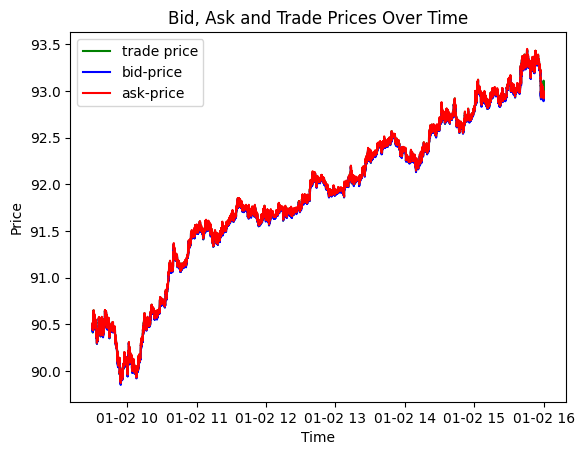

In [ ]:
plt.plot(merged_df.index, merged_df['trade-price'], color='green', label='trade price')
plt.plot(merged_df.index, merged_df['bid-price'], color='blue', label='bid-price')
plt.plot(merged_df.index, merged_df['ask-price'], color='red', label='ask-price')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Bid, Ask and Trade Prices Over Time')
plt.show()


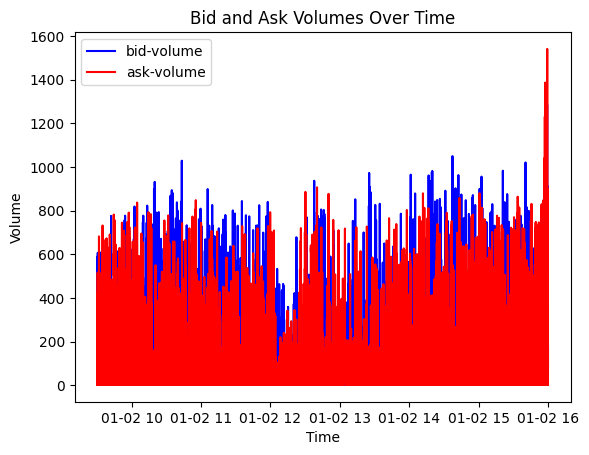

In [ ]:
plt.plot(merged_df.index, merged_df['bid-volume'], color='blue', label='bid-volume')
plt.plot(merged_df.index, merged_df['ask-volume'], color='red', label='ask-volume')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Volume')
plt.title('Bid and Ask Volumes Over Time')
plt.show()

In [ ]:
new_df = pd.DataFrame()
new_df["xltime"] = merged_df.index
new_df.set_index('xltime', inplace=True)
new_df["mid-price"] = merged_df["mid-price"]

In [ ]:
deltas = np.linspace(1, 100, 21)
deltas = np.unique(np.round(deltas)).astype(int)

for delta in deltas:
    new_df["shifted-mid-price"] = new_df["mid-price"].shift(delta)
    new_df = new_df.dropna()
    new_df[f"log-ret (delta={delta})"] = np.log(new_df["mid-price"]) - np.log(new_df["shifted-mid-price"])

#print(new_df.head())

c:\Users\raphe\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


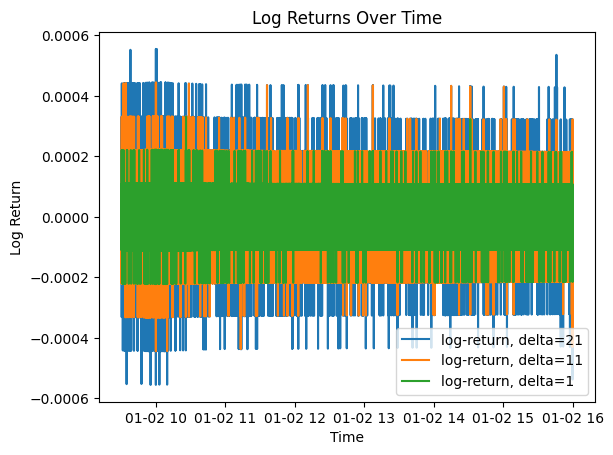

In [ ]:
deltas_to_plot = deltas[0:5:2]
deltas_to_plot = deltas_to_plot[::-1]
for delta in deltas_to_plot:
    plt.plot(new_df.index, new_df[f"log-ret (delta={delta})"], label=f'log-return, delta={delta}')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.title('Log Returns Over Time')
plt.show()

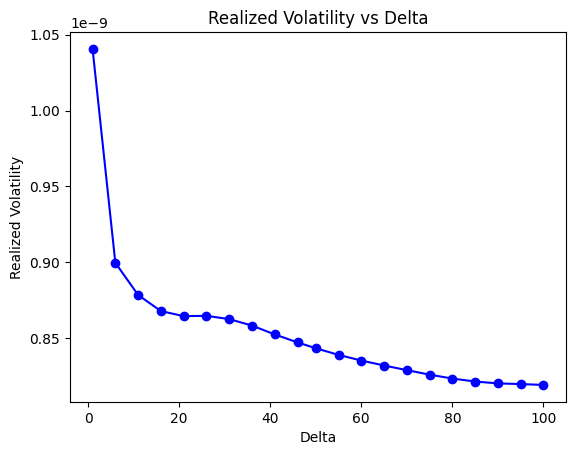

In [ ]:
realized_vol = []
T = new_df.shape[0]
for delta in deltas:
    realized_vol.append(1/(T*delta) * np.sum(new_df[f"log-ret (delta={delta})"]**2))

plt.plot(deltas, realized_vol, color='blue', marker='o')
plt.xlabel('Delta')
plt.ylabel('Realized Volatility')
plt.title('Realized Volatility vs Delta')
plt.show()


In [ ]:
df_5min = merged_df.copy()
df_5min["diff_time"] = df_5min.index.diff().total_seconds()
df_5min = df_5min.groupby(pd.Grouper(freq='5Min')).mean()
df_5min = df_5min.dropna()

df_5min.head()

,bid-price,bid-volume,ask-price,ask-volume,trade-price,trade-volume,mid-price,weighted-price,spread,relative-spread,diff_time
xltime,,,,,,,,,,,
2009-01-02 09:30:00-05:00,90.474929,58.173951,90.488305,54.239201,90.479426,310.378193,90.481665,90.481220,0.013377,0.000136,0.055331
2009-01-02 09:35:00-05:00,90.469613,60.871749,90.483571,63.054086,90.476095,245.738659,90.477013,90.476678,0.013958,0.000142,0.062521
2009-01-02 09:40:00-05:00,90.525255,66.074075,90.539302,61.738205,90.531504,260.256969,90.531913,90.532324,0.014047,0.000142,0.063183
2009-01-02 09:45:00-05:00,90.422387,60.563774,90.437116,62.674720,90.429485,276.847068,90.429730,90.430040,0.014729,0.000149,0.086176
2009-01-02 09:50:00-05:00,90.077118,69.901784,90.092146,65.964951,90.084540,279.105502,90.084533,90.085000,0.015028,0.000152,0.064847


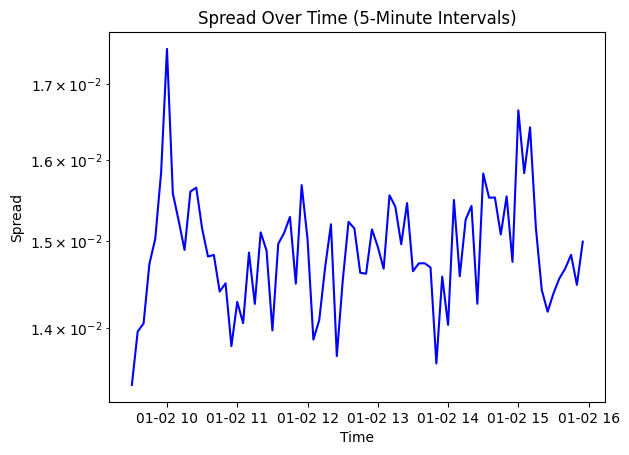

In [ ]:
plt.plot(df_5min.index, df_5min['spread'], color='blue')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.yscale('log')
plt.title('Spread Over Time (5-Minute Intervals)')
plt.show()

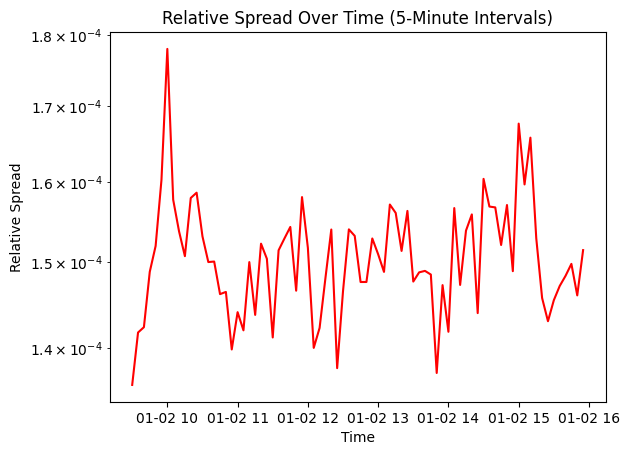

In [ ]:
plt.plot(df_5min.index, df_5min['relative-spread'], color='red')
plt.xlabel('Time')
plt.ylabel('Relative Spread')
plt.yscale('log')
plt.title('Relative Spread Over Time (5-Minute Intervals)')
plt.show()

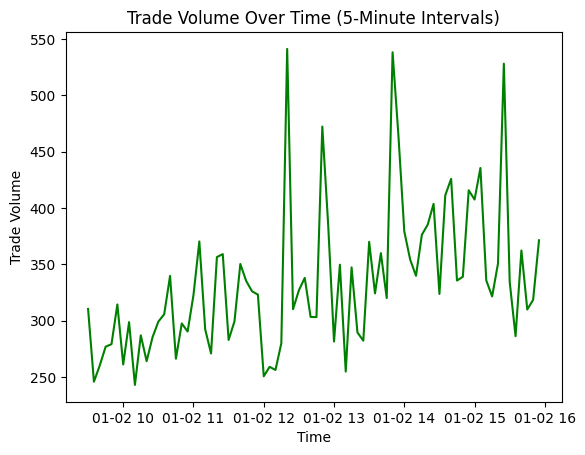

In [ ]:
plt.plot(df_5min.index, df_5min['trade-volume'], color='green')
plt.xlabel('Time')
plt.ylabel('Trade Volume')
plt.title('Trade Volume Over Time (5-Minute Intervals)')
plt.show()

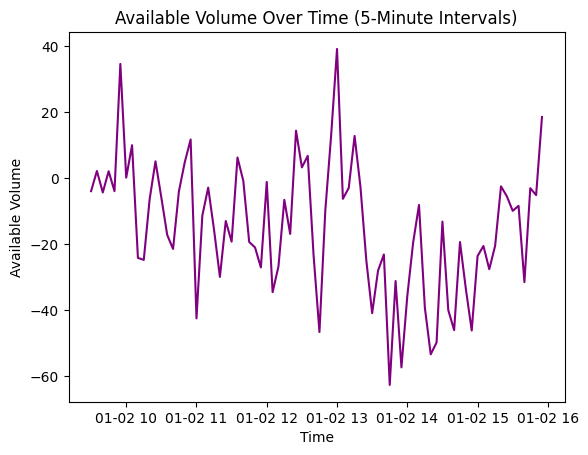

In [ ]:
plt.plot(df_5min.index, df_5min['ask-volume']-df_5min['bid-volume'], color='purple')
plt.xlabel('Time')
plt.ylabel('Available Volume')
plt.title('Available Volume Over Time (5-Minute Intervals)')
plt.show()

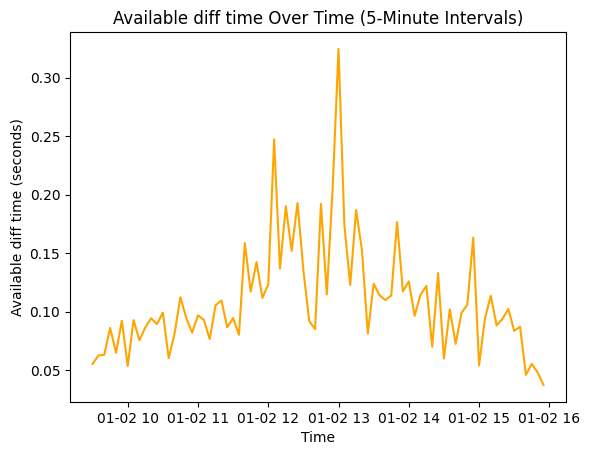

In [ ]:
plt.plot(df_5min.index, df_5min['diff_time'], color='orange')
plt.xlabel('Time')
plt.ylabel('Available diff time (seconds)')
plt.title('Available diff time Over Time (5-Minute Intervals)')
plt.show()

In [ ]:
df_5min_med = merged_df.copy()
df_5min_med = df_5min_med.groupby(pd.Grouper(freq='5Min')).median()
df_5min_med = df_5min_med.dropna()

df_5min_med.head()

,bid-price,bid-volume,ask-price,ask-volume,trade-price,trade-volume,mid-price,weighted-price,spread,relative-spread
xltime,,,,,,,,,,
2009-01-02 09:30:00-05:00,90.48,48.0,90.50,42.0,90.486667,233.333333,90.485,90.49,0.010000,0.0001
2009-01-02 09:35:00-05:00,90.47,58.0,90.48,57.0,90.480000,200.000000,90.480,90.48,0.010000,0.0001
2009-01-02 09:40:00-05:00,90.54,49.0,90.55,57.0,90.550000,200.000000,90.540,90.55,0.010000,0.0001
2009-01-02 09:45:00-05:00,90.44,47.0,90.46,52.0,90.450000,209.090909,90.450,90.45,0.010000,0.0001
2009-01-02 09:50:00-05:00,90.08,39.0,90.10,47.0,90.090000,225.000000,90.090,90.09,0.013333,0.0001


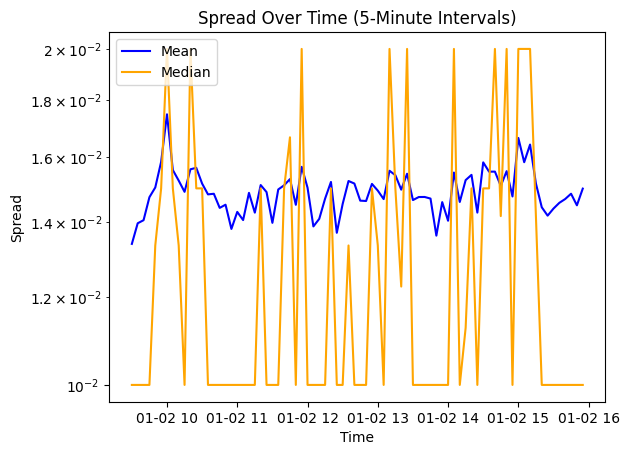

In [ ]:
plt.plot(df_5min.index, df_5min['spread'], color='blue', label='Mean')
plt.plot(df_5min_med.index, df_5min_med['spread'], color='orange', label='Median')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.yscale('log')
plt.legend()
plt.title('Spread Over Time (5-Minute Intervals)')
plt.show()

In [ ]:
def proper_datetime_FR(df):
    df['xltime'] = pd.to_datetime(df['xltime'], unit='D', origin='1899-12-30', utc=True)
    df = df.set_index('xltime')
    df = df.tz_convert('Europe/Paris')
    df = df.between_time('09:00', '17:30')
    return df

In [ ]:
df_FR = pd.read_csv('data/raw/TRTH/equity/FR/bbo/TOTF.PA/2009-01-02-TOTF.PA-bbo.csv.gz')
df_FR = proper_datetime_FR(df_FR)
df_FR["mid-price"] = (df_FR["bid-price"] + df_FR["ask-price"]) / 2
df_FR["mid-price"] = round(df_FR["mid-price"], 2)
df_FR["weighted-price"] = (df_FR["bid-price"]*df_FR["bid-volume"] + df_FR["ask-price"]*df_FR["ask-volume"]) / (df_FR["bid-volume"]+df_FR["ask-volume"])
df_FR["weighted-price"] = round(df_FR["weighted-price"], 2)
df_FR["spread"] = df_FR["ask-price"] - df_FR["bid-price"]
df_FR["relative-spread"] = df_FR["spread"] / df_FR["mid-price"]
df_FR["relative-spread"] = round(df_FR["relative-spread"], 4)

df_FR.head()

,bid-price,bid-volume,ask-price,ask-volume,mid-price,weighted-price,spread,relative-spread
xltime,,,,,,,,
2009-01-02 09:00:00.005000431+01:00,38.975,31,39.00,60,38.99,38.99,0.025,0.0006
2009-01-02 09:00:00.541000094+01:00,38.975,31,39.12,117,39.05,39.09,0.145,0.0037
2009-01-02 09:00:00.604000779+01:00,38.975,31,39.00,100,38.99,38.99,0.025,0.0006
2009-01-02 09:00:00.733000152+01:00,38.975,31,39.00,200,38.99,39.00,0.025,0.0006
2009-01-02 09:00:00.748000203+01:00,38.975,131,39.00,200,38.99,38.99,0.025,0.0006


In [ ]:
df_FR_5min = df_FR.copy()
df_FR_5min["diff_time"] = df_FR_5min.index.diff().total_seconds()
df_FR_5min = df_FR_5min.groupby(pd.Grouper(freq='5Min')).mean()
df_FR_5min = df_FR_5min.dropna()

df_FR_5min.head()

,bid-price,bid-volume,ask-price,ask-volume,mid-price,weighted-price,spread,relative-spread,diff_time
xltime,,,,,,,,,
2009-01-02 09:00:00+01:00,38.794012,1816.312094,38.884577,1969.910273,38.839467,38.845176,0.090566,0.002333,0.389465
2009-01-02 09:05:00+01:00,38.841163,1402.786096,38.911805,1052.657754,38.876631,38.877246,0.070642,0.001817,0.804318
2009-01-02 09:10:00+01:00,38.957736,967.797802,39.014560,1867.287912,38.986967,38.992286,0.056824,0.001459,0.652110
2009-01-02 09:15:00+01:00,39.073584,1618.019830,39.131331,2238.135977,39.102748,39.105156,0.057748,0.001474,0.855057
2009-01-02 09:20:00+01:00,39.210291,1671.072816,39.259539,1941.669903,39.235243,39.236505,0.049248,0.001244,1.461170


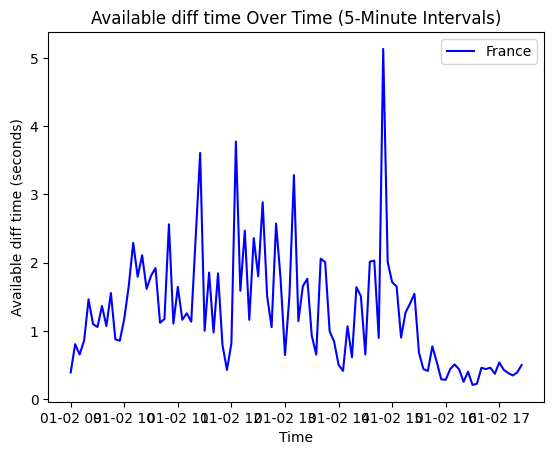

In [ ]:
plt.plot(df_FR_5min.index, df_FR_5min['diff_time'], color='blue')
plt.xlabel('Time')
plt.ylabel('Available diff time (seconds)')
plt.title('Available diff time Over Time (5-Minute Intervals)')
plt.show()

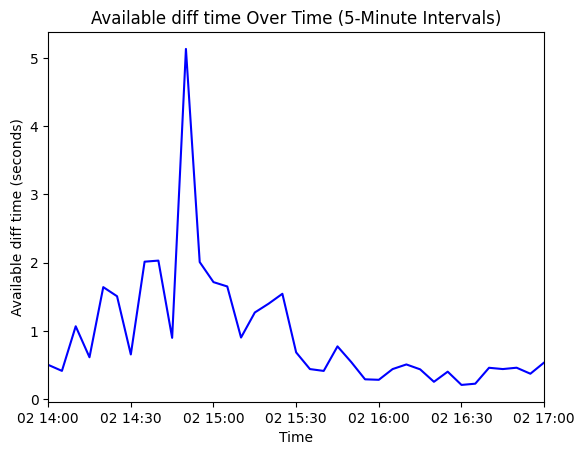

In [ ]:
# zoom on 14 to 16
plt.plot(df_FR_5min.index, df_FR_5min['diff_time'], color='blue')
plt.xlabel('Time')
plt.ylabel('Available diff time (seconds)')
plt.title('Available diff time Over Time (5-Minute Intervals)')
plt.xlim(pd.Timestamp('2009-01-02 13:00:00'), pd.Timestamp('2009-01-02 16:00'))
plt.show()

In [ ]:
side = np.sign(merged_df["trade-price"] - merged_df["mid-price"])
side = side[side != 0]
print(side.value_counts())
print(side.

-1.0    71498
 1.0    56625
Name: count, dtype: int64


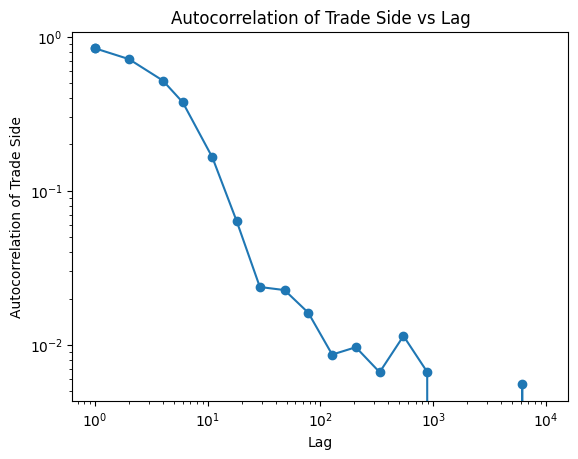

In [ ]:
lag_vec = np.logspace(0, 4, 20).astype(int)
autocorr_side = []
for lag in lag_vec:
    autocorr_side.append(merged_df["side"].autocorr(lag=lag))
plt.plot(lag_vec, autocorr_side, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation of Trade Side')
plt.title('Autocorrelation of Trade Side vs Lag')
plt.show()

C'est normal que ca soit pas beau apres 1000 parce qu'il me faudrait 1 million de trade et j'en ai 150 000.